**Multi-Head Attention готов.** Теперь каждый токен «пообщался» с другими токенами и получил контекстную информацию. Но на этом обработка не заканчивается!

В этом модуле мы добавим **Feed-Forward Network (FFN)** - нейросеть, которая обрабатывает информацию каждого токена независимо. Это как если бы после обсуждения с коллегами (Attention) каждый сотрудник самостоятельно обдумывал полученную информацию.

**Проблема:** Attention только смешивает информацию между токенами. Он не обрабатывает и не преобразует эту информацию!

**Аналогия:**

*Attention - это как совещание, где все обмениваются мнениями.*

*Но после совещания каждый должен самостоятельно обдумать полученную информацию и принять решение.*

**Вот как раз это решает Feed-Forward Network (FFN) - это простая нейросеть, которая применяется к каждому токену независимо.**



Что она делает:

1. Обрабатывает информацию, которую токен получил от Attention
2. Преобразует её в новое представление
3. Добавляет нелинейность (через функцию активации)

**Ключевое отличие от Attention:**

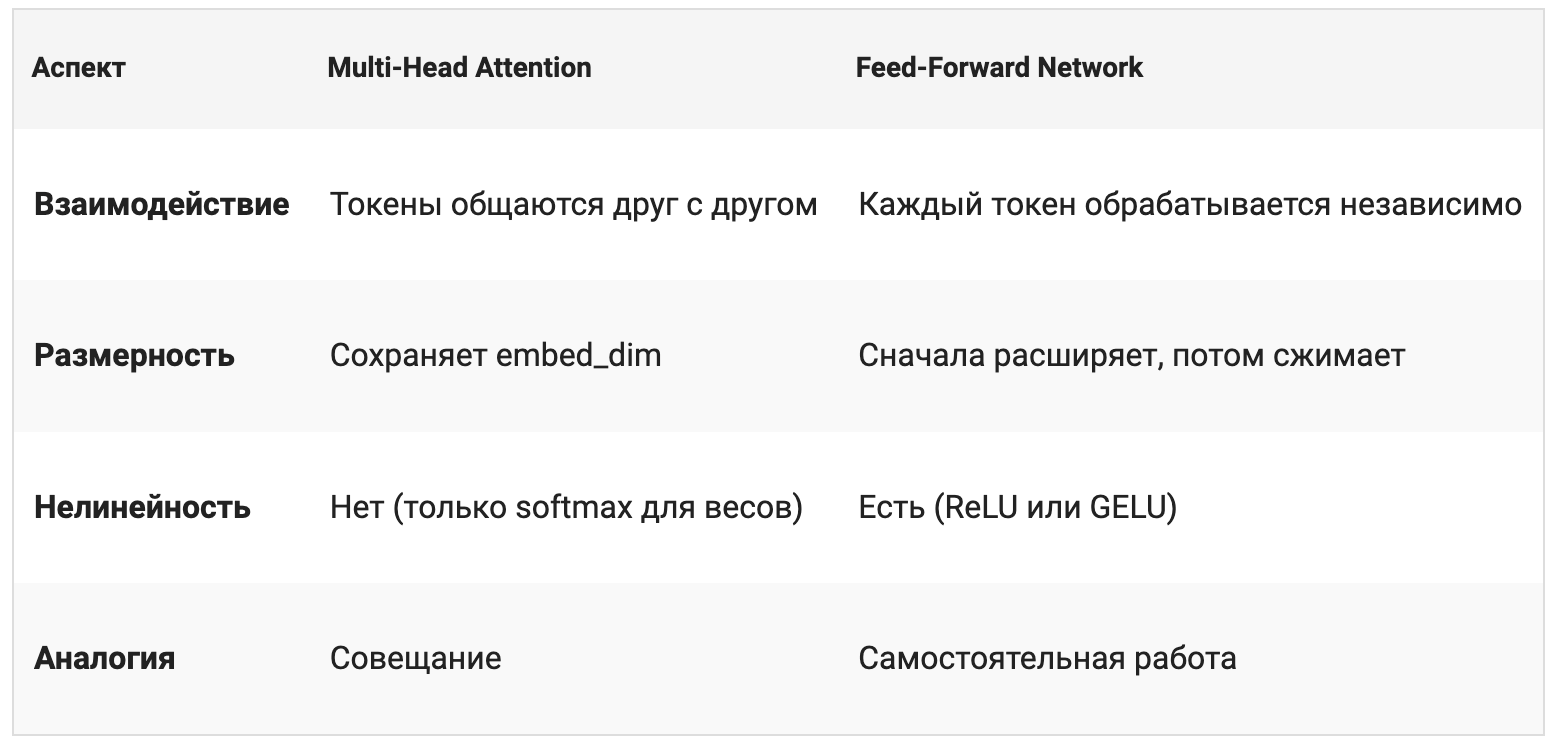

## Структура FFN

FFN состоит из двух линейных слоёв с функцией активации между ними:

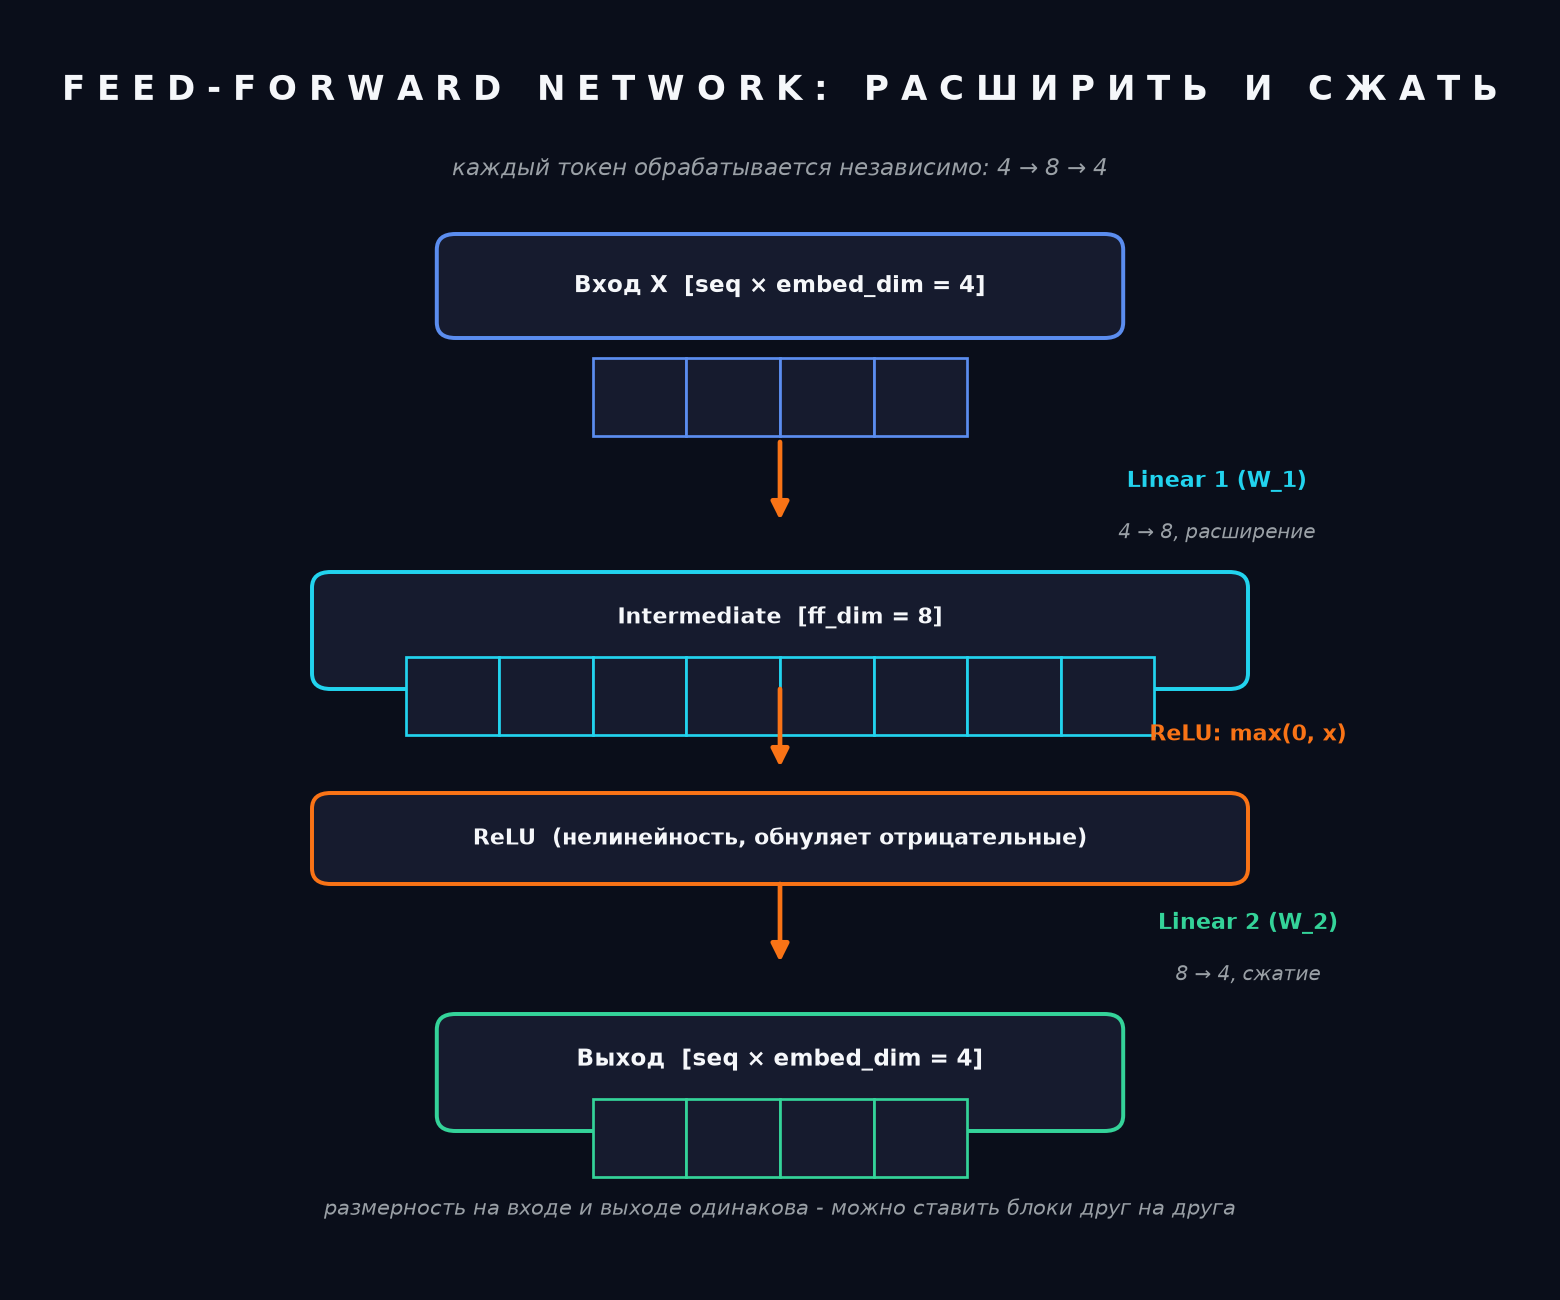

**Параметры:**

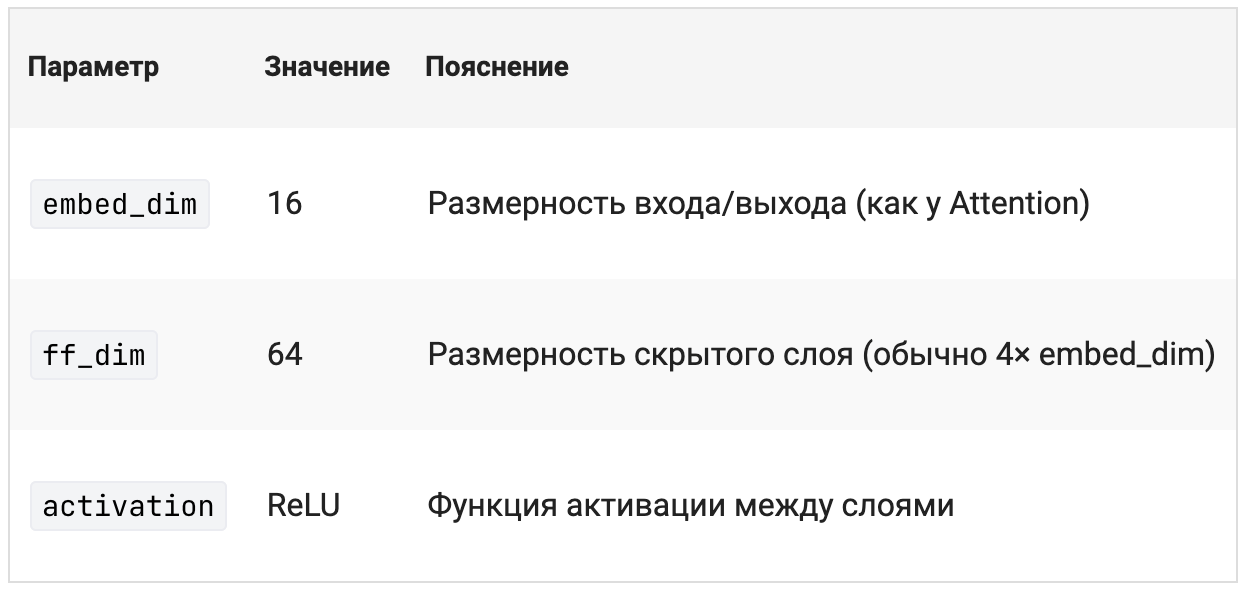

Возьмём выходные данные от Multi-Head Attention (это ровно та итоговая матрица, которой закончился прошлый модуль):

$$
\mathrm{X} =
\begin{bmatrix}
0.7484 & 0.8509 & 0.7282 & 0.8056 \\
0.7579 & 0.8647 & 0.7364 & 0.8144 \\
0.7588 & 0.8659 & 0.7372 & 0.8154
\end{bmatrix}
$$

**Параметры:**

`embed_dim = 4` (уменьшим для наглядности вычислений)

`ff_dim = 8` (в 2 раза больше для примера)

`seq_length = 3` (3 токена)

**Матрица $W_1$ (первый линейный слой)**

Размер: `[embed_dim, ff_dim] = [4, 8]`

$$
W_1 =
\begin{bmatrix}
0.5 & 0.2 & 0.1 & 0.3 & 0.4 & 0.2 & 0.1 & 0.2 \\
0.3 & 0.6 & 0.2 & 0.1 & 0.2 & 0.5 & 0.3 & 0.1 \\
0.1 & 0.1 & 0.7 & 0.2 & 0.3 & 0.1 & 0.6 & 0.2 \\
0.2 & 0.3 & 0.1 & 0.5 & 0.1 & 0.2 & 0.1 & 0.7
\end{bmatrix}
$$

Что делает $W_1$:

- Проецирует вход из `embed_dim` (4) в `ff_dim` (8)
- Расширяет пространство признаков

**Матрица $W_2$ (первый линейный слой)**

Размер: `[ff_dim, embed_dim] = [8, 4]`

$$
W_2 =
\begin{bmatrix}
0.5 & 0.2 & 0.1 & 0.3 \\
0.3 & 0.6 & 0.2 & 0.1 \\
0.1 & 0.1 & 0.7 & 0.2 \\
0.2 & 0.3 & 0.1 & 0.5 \\
0.4 & 0.2 & 0.3 & 0.1 \\
0.2 & 0.5 & 0.1 & 0.3 \\
0.1 & 0.3 & 0.6 & 0.2 \\
0.3 & 0.1 & 0.2 & 0.6
\end{bmatrix}
$$

Что делает $W_2$:

- Проецирует из `ff_dim` (8) обратно в `embed_dim` (4)
- Сжимает пространство признаков

**Вектор смещения (bias)**

Для простоты вычислений будем считать bias = 0. В реальной реализации bias есть, но он не меняет сути вычислений.

Аналогично, важно понимать, что веса в матрицах $W_1$ и $W_2$ сначала задаются случайно, а затем подбираются в ходе обучения.

Сейчас получим **матрицу Intermediate**.

Матрица Intermediate - это промежуточный результат работы Feed-Forward Network, который получается после первого линейного слоя (Linear 1) и до применения функции активации ReLU.

Простыми словами: каждый токен пришёл на консультацию к специалисту. Входной вектор токена (4 числа) - это его исходный «запрос». Матрица $W_1$ - это «знания специалиста». Результат - Intermediate (8 чисел) - это «развёрнутый анализ», где специалист рассмотрел запрос с разных сторон.

По сути Intermediate - это умножение входной матрицы $X$ на весовую матрицу $W_1$

$$Intermediate = X @ W_1 = [3\times4]@[4\times8]=[3\times8]$$

$$
\mathrm{Intermediate} =
\begin{bmatrix}
0.8634 & 0.9747 & 0.8353 & 0.8580 & 0.7686 & 0.8091 & 0.8476 & 0.9443 \\
0.8749 & 0.9884 & 0.8457 & 0.8683 & 0.7785 & 0.8205 & 0.8585 & 0.9554 \\
0.8760 & 0.9896 & 0.8466 & 0.8694 & 0.7794 & 0.8215 & 0.8595 & 0.9566
\end{bmatrix}
$$

**ReLU (Rectified Linear Unit)** - это функция активации, которая обнуляет все отрицательные значения:

$$ReLU(x) = max(0, x)$$

**В нашей матрице Intermediate все значения положительные, поэтому ReLU ничего не меняет**

Если первый слой (Linear 1) был как «расширение мысли» - когда вы берёте простую идею и раскладываете её на много деталей, то второй слой (Linear 2) - это «сжатие к главному». После того как модель рассмотрела токен с 8 разных сторон, ей нужно выделить самое важное и вернуть всё к исходному размеру.

Linear 2 - это второй линейный слой в Feed-Forward Network, который проецирует расширенное представление (`ff_dim = 8`) обратно к исходной размерности (`embed_dim = 4`).

Формула 2-го слоя:

$$Output = ReLU(Intermediate)@W_2 = [3\times8]@[8\times4]=[3\times4]$$

Итого:

$$
\mathrm{Output} =
\begin{bmatrix}
1.8166 & 2.0054 & 1.9607 & 2.0083 \\
1.8401 & 2.0321 & 1.9857 & 2.0335 \\
1.8424 & 2.0346 & 1.9881 & 2.0360
\end{bmatrix}
$$

***Сравнение: вход vs выход FFN***

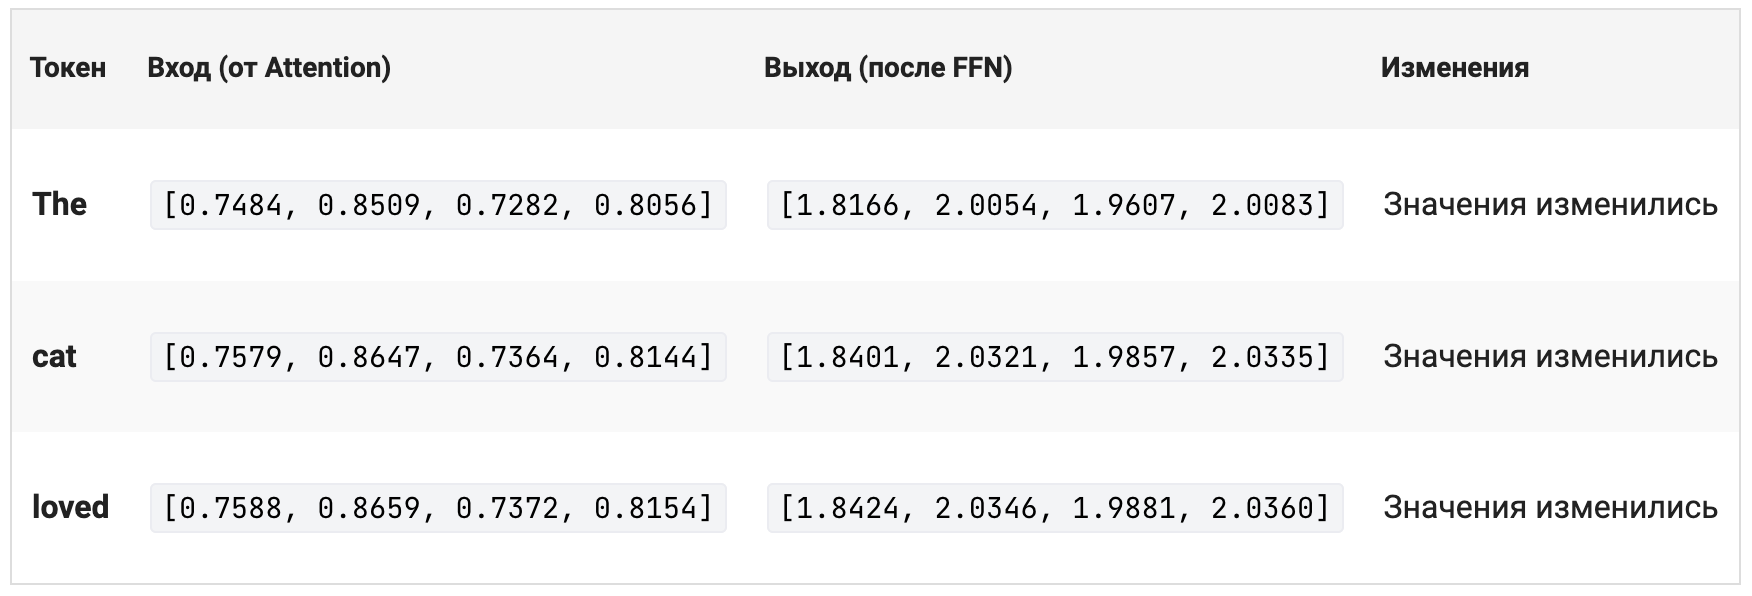

**Наблюдения:**

1. Размерность сохранилась: вход [3×4], выход [3×4]
2. Значения изменились: FFN преобразовал представления токенов
3. Токены обрабатывались независимо: каждый токен проходил через FFN отдельно

Всего в нашем feed-forward слое $2 \cdot 32 = 64$ параметра. В современных моделях миллиарды параметров!

Теперь реализуем всё это в коде (`feed_forward.py`).